In [1]:
import numpy as np
import kwant
import matplotlib.pyplot as plt

from sympy import Matrix, nsimplify
from IPython.display import display

In [2]:
# This cell is just to highlight some of the important cells

from IPython.display import display, HTML
from IPython.core.magic import register_cell_magic
import uuid

display(HTML("""
<style>
.tutorial-note {
    padding: 12px 16px;
    margin: 12px 0;
    border-left: 5px solid #4c8bf5;
    background: rgba(76, 139, 245, 0.08);
    border-radius: 4px;
}

.tutorial-important {
    padding: 12px 16px;
    margin: 12px 0;
    border-left: 5px solid #e67e22;
    background: rgba(230, 126, 34, 0.08);
    border-radius: 4px;
}

.tutorial-warning {
    padding: 12px 16px;
    margin: 12px 0;
    border-left: 5px solid #d9534f;
    background: rgba(217, 83, 79, 0.08);
    border-radius: 4px;
}

.tutorial-result {
    padding: 12px 16px;
    margin: 12px 0;
    border-left: 5px solid #2ca02c;
    background: rgba(44, 160, 44, 0.08);
    border-radius: 4px;
}
</style>
"""))



@register_cell_magic
def important(line, cell):
    marker = f"important-{uuid.uuid4().hex}"

    display(HTML(f"""
    <div id="{marker}"></div>

    <style>
    .jp-CodeCell:has(#{marker}) {{
        background: rgba(230, 126, 34, 0.08);
        border-left: 5px solid #e67e22;
        border-radius: 5px;
        padding-left: 6px;
    }}
    </style>
    """))

    get_ipython().run_cell(cell)

In [3]:
def show_matrix(M):
    display(Matrix(np.asarray(M)).applyfunc(nsimplify))

In [4]:
%%important

def onsite_clean(site, mu, Delta, J):

    h = -mu * s0
    pairing = 1j * Delta * sy

    return np.block([
        [h, pairing],
        [pairing.conj().T, -h.T]
    ])


def hopping_bdg(t):

    he = -t * s0

    return np.block([
        [he, z2],
        [z2, -he.conj()]
    ])


def onsite_impurity(site, mu, Delta, J):

    h = -mu * s0 + J * sz
    pairing = 1j * Delta * sy

    return np.block([
        [h, pairing],
        [pairing.conj().T, -h.T]
    ])

In [6]:
s0 = np.eye(2, dtype=complex)

sx = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

sy = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sz = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

z2 = np.zeros((2, 2), dtype=complex)

## Here we construct the square-octagon lattice.

In [7]:
sqrt2 = np.sqrt(2)

a1 = (1 + sqrt2, 0)
a2 = (0, 1 + sqrt2)

s = 1 / sqrt2

basis = [
    (0, s),       # A
    (-s, 0),      # B
    (0, -s),      # C
    (s, 0)        # D
]

In [8]:
# Here norbs=4 because every physical lattice site carries the four-component Nambu spinor.

lat = kwant.lattice.general(
    [a1, a2],
    basis=basis,
    norbs=4,
    name="sqo"
)

A, B, C, D = lat.sublattices


NN_HOPS = [
    kwant.builder.HoppingKind((0, 0), A, B),
    kwant.builder.HoppingKind((0, 0), B, C),
    kwant.builder.HoppingKind((0, 0), C, D),
    kwant.builder.HoppingKind((0, 0), D, A),

    kwant.builder.HoppingKind((0, 1), C, A),
    kwant.builder.HoppingKind((1, 0), B, D),
]

NNN_HOPS = [
    kwant.builder.HoppingKind((0, 0), A, C),
    kwant.builder.HoppingKind((0, 0), B, D),
]

In [9]:
Nx = 2
Ny = 2

syst = kwant.Builder()

for ix in range(Nx):
    for iy in range(Ny):

        # whenever onsite Hamiltonian is needed this function will be used. Kwant stores the callable.
        syst[A(ix, iy)] = onsite_clean
        syst[B(ix, iy)] = onsite_clean
        syst[C(ix, iy)] = onsite_clean
        syst[D(ix, iy)] = onsite_clean

In [10]:
t1 = 1.0
t2 = 0.5

for hop in NN_HOPS:
    syst[hop] = hopping_bdg(t1)

for hop in NNN_HOPS:
    syst[hop] = hopping_bdg(t2)

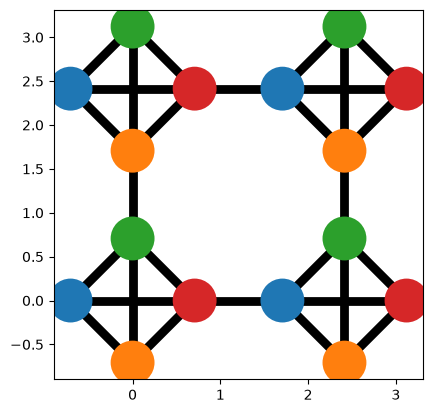

In [11]:
kwant.plot(syst);

<div class="tutorial-note">
    We can collect all the above into one function `build_ysr_system`
</div>

In [23]:
%%important

SUBLATTICES = {
    "A": A,
    "B": B,
    "C": C,
    "D": D
}


def build_ysr_system(
    Nx, Ny,
    t1=1.0, t2=1.0,
    impurity_sublattice="A",
    impurity_cell=None
):

    if impurity_cell is None:
        impurity_cell = (Nx // 2, Ny // 2)

    impurity_site = SUBLATTICES[
        impurity_sublattice
    ](*impurity_cell)

    syst = kwant.Builder()

    # Sites
    for ix in range(Nx):
        for iy in range(Ny):

            syst[A(ix, iy)] = onsite_clean
            syst[B(ix, iy)] = onsite_clean
            syst[C(ix, iy)] = onsite_clean
            syst[D(ix, iy)] = onsite_clean

    # Replace one clean onsite by magnetic impurity
    syst[impurity_site] = onsite_impurity

    # Hoppings
    for hop in NN_HOPS:
        syst[hop] = hopping_bdg(t1)

    for hop in NNN_HOPS:
        syst[hop] = hopping_bdg(t2)

    fsyst = syst.finalized()

    impurity_index = fsyst.id_by_site[
        impurity_site
    ]

    return fsyst, impurity_site, impurity_index

<div class="tutorial-note">

We can start with a simple $1 \times 1$ square-octagon system. It has only four physical sites:

$$
A,B,C,D.
$$

Each has four BdG orbitals, so the full Hamiltonian is

$$
4\times4=16
$$

dimensional and that is small enough to inspect directly.

</div>

In [11]:
fsyst, impurity_site, impurity_index = build_ysr_system(
    Nx=1, Ny=1,
    t1=1.0, t2=0.5,
    impurity_sublattice="A",
    impurity_cell=(0, 0)
)

**IMPORTANT:** While Kwant identifies the sublattice families as A, B, C and D, their order inside the finalized Kwant Hamiltonian is not guaranteed to be A-B-C-D. so we need to figure that out first if we want to know about it. This doesn't matter if Hamiltonian is what we are concerned with.

In [14]:
site_A = A(0, 0)
site_B = B(0, 0)
site_C = C(0, 0)
site_D = D(0, 0)

iA = fsyst.id_by_site[site_A]
iB = fsyst.id_by_site[site_B]
iC = fsyst.id_by_site[site_C]
iD = fsyst.id_by_site[site_D]

print("A index =", iA)
print("B index =", iB)
print("C index =", iC)
print("D index =", iD)

A index = 2
B index = 0
C index = 1
D index = 3


<div class="tutorial-note">
So the complete $16$-component basis for the Hamiltonian would be:

$$
\begin{aligned}
(&B_\uparrow,
B_\downarrow,
B_\uparrow^\dagger,
B_\downarrow^\dagger,\\
&C_\uparrow,
C_\downarrow,
C_\uparrow^\dagger,
C_\downarrow^\dagger,\\
&A_\uparrow,
A_\downarrow,
A_\uparrow^\dagger,
A_\downarrow^\dagger,\\
&D_\uparrow,
D_\downarrow,
D_\uparrow^\dagger,
D_\downarrow^\dagger).
\end{aligned}
$$
</div>

In [16]:
params = {
    "mu": 0.3,
    "Delta": 0.2,
    "J": 0.4
}

H = fsyst.hamiltonian_submatrix(
    params=params,
    sparse=False
)

print(H.shape)
Matrix(H)

(16, 16)


Matrix([
[-0.3,    0,    0, 0.2, -1.0,    0,    0,   0, -1.0,    0,    0,   0, -0.5,    0,    0,   0],
[   0, -0.3, -0.2,   0,    0, -1.0,    0,   0,    0, -1.0,    0,   0,    0, -0.5,    0,   0],
[   0, -0.2,  0.3,   0,    0,    0,  1.0,   0,    0,    0,  1.0,   0,    0,    0,  0.5,   0],
[ 0.2,    0,    0, 0.3,    0,    0,    0, 1.0,    0,    0,    0, 1.0,    0,    0,    0, 0.5],
[-1.0,    0,    0,   0, -0.3,    0,    0, 0.2, -0.5,    0,    0,   0, -1.0,    0,    0,   0],
[   0, -1.0,    0,   0,    0, -0.3, -0.2,   0,    0, -0.5,    0,   0,    0, -1.0,    0,   0],
[   0,    0,  1.0,   0,    0, -0.2,  0.3,   0,    0,    0,  0.5,   0,    0,    0,  1.0,   0],
[   0,    0,    0, 1.0,  0.2,    0,    0, 0.3,    0,    0,    0, 0.5,    0,    0,    0, 1.0],
[-1.0,    0,    0,   0, -0.5,    0,    0,   0,  0.1,    0,    0, 0.2, -1.0,    0,    0,   0],
[   0, -1.0,    0,   0,    0, -0.5,    0,   0,    0, -0.7, -0.2,   0,    0, -1.0,    0,   0],
[   0,    0,  1.0,   0,    0,    0,  0.5,   0,    0

In [17]:
H_A = H[4*iA:4*iA+4, 4*iA:4*iA+4]
H_B = H[4*iB:4*iB+4, 4*iB:4*iB+4]
H_C = H[4*iC:4*iC+4, 4*iC:4*iC+4]
H_D = H[4*iD:4*iD+4, 4*iD:4*iD+4]

In [18]:
print("A onsite")
display(Matrix(H_A))

print("B onsite")
display(Matrix(H_B))

print("C onsite")
display(Matrix(H_C))

print("D onsite")
display(Matrix(H_D))

A onsite


Matrix([
[0.1,    0,    0, 0.2],
[  0, -0.7, -0.2,   0],
[  0, -0.2, -0.1,   0],
[0.2,    0,    0, 0.7]])

B onsite


Matrix([
[-0.3,    0,    0, 0.2],
[   0, -0.3, -0.2,   0],
[   0, -0.2,  0.3,   0],
[ 0.2,    0,    0, 0.3]])

C onsite


Matrix([
[-0.3,    0,    0, 0.2],
[   0, -0.3, -0.2,   0],
[   0, -0.2,  0.3,   0],
[ 0.2,    0,    0, 0.3]])

D onsite


Matrix([
[-0.3,    0,    0, 0.2],
[   0, -0.3, -0.2,   0],
[   0, -0.2,  0.3,   0],
[ 0.2,    0,    0, 0.3]])